# Machine Learning 지도학습 - 분류


## ⚙️환경설정


In [1]:
from cProfile import label

from jsonschema.benchmarks.import_benchmark import import_time
from numpy.ma.core import indices
from pandas.core.sample import sample
from scipy.spatial import distance
from sklearn import neighbors
# scikit-learn 설치
!pip install scikit-learn -q

In [2]:
import sklearn
sklearn.__version__

'1.9.0'

In [3]:
# 라이브러리와 한글 폰트 설정
from pathlib import Path
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display

# 운영체제별 한글 폰트 후보
font_candidates = {
    "Darwin": ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Windows": ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}

available_fonts = {font.name for font in fm.fontManager.ttflist}
selected_font = None

for font_name in font_candidates.get(platform.system(), []):
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:
    plt.rcParams["font.family"] = selected_font
    print("설정된 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", rc={"axes.unicode_minus": False})
if selected_font:
    sns.set_theme(style="whitegrid", rc={"font.family": selected_font, "axes.unicode_minus": False})

설정된 한글 폰트: AppleGothic


## 생선 이진 분류 - 도미냐? 빙어냐?
<table>
    <tr>
        <td><img src="https://d.pr/i/FaQ4RH+" width="300"></td>
        <td><img src="https://d.pr/i/NmXwPX+" width="300"></td>
    </tr>
</table>


In [4]:
# 도미와 빙어의 길이/무게 원자료

# 도미 bream 데이터 35개
# bream_length: 도미 35마리의 길이
# bream_weight: 도미 35마리의 무게
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

# 빙어 smelt 데이터 14개
# smelt_length: 빙어 14마리의 길이
# smelt_weight: 빙어 14마리의 무게
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

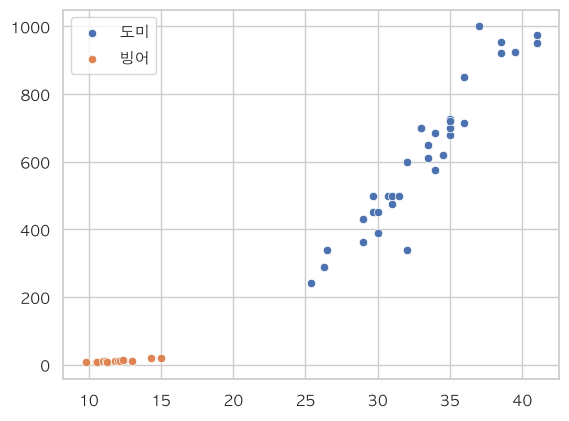

In [5]:
# 산점도표를 이용해서 도미와 빙어의 분포 확인
sns.scatterplot(
    x=bream_length, y=bream_weight, label = '도미'
)

sns.scatterplot(
    x=smelt_length, y=smelt_weight, label = '빙어'
)

plt.legend()
plt.show()

## KNN K-최근접이웃분류모델
데이터포인트간의 거리기반으로 분류를 수행하는 모델


### k-최근접 이웃 알고리즘 작동원리

최근접이웃(K-Nearest Neighbors, KNN)에서 거리를 구하는 방법으로 가장 일반적으로 사용되는 방법은 **유클리드 거리(Euclidean distance)**이다.

유클리드 거리란 "두 점 사이의 직선 거리" 를 구하는 가장 간단한 방법이다.

좌표상 (0, 0)과 (3, 4)라는 점 두 개를 찍었다고 하자. 이 두 점을 선으로 연결하면, 바로 그 선의 길이가 유클리드 거리이다!

$$\text { 거리 }=\sqrt{\left(x_{2}-x_{1}\right)^{2}+\left(y_{2}-y_{1}\right)^{2}}$$

두 점 $p = (p_1, p_2, ..., p_n)$과 $q = (q_1, q_2, ..., q_n)$ 사이의 유클리드 거리는 다음과 같은 수식으로 계산된다.

$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \cdots + (p_n - q_n)^2}$$

#### 다양한 거리계산법
이 외에도 거리 계산에 사용하는 방법에는 **맨해튼 거리(Manhattan distance)**, **민코프스키 거리(Minkowski distance)**, **코사인 유사도(Cosine similarity)** 등이 있다.

1. 맨해튼 거리 계산식:

$$d(p, q) = |p_1 - q_1| + |p_2 - q_2| + \cdots + |p_n - q_n|$$

2. 민코프스키 거리 계산식(유클리드와 맨해튼 거리를 일반화한 형태):
  (여기서 $p = 2$일 때는 유클리드 거리, $p = 1$일 때는 맨해튼 거리이다)
$$d(p, q) = \left( \sum_{i=1}^{n} |p_i - q_i|^p \right)^{1/p}$$

3. 코사인 유사도:
  (여기서 $p \cdot q$는 두 벡터의 내적, $\|p\|$와 $\|q\|$는 벡터의 크기이다)
$$\cos \theta = \frac{p \cdot q}{\|p\| \|q\|}$$



In [6]:
# 도미와 빙어 데이터를 모델 입력용 데이터 X로 변환

# 도미와 빙어의 길이 무게 list를 단순히 이어붙이는 것
fish_length = bream_length + smelt_length # 35 + 14 = 49개의 데이터
fish_weight = bream_weight + smelt_weight # 35 + 14 = 49개의 데이터

print(len(fish_length), len(fish_weight))

fish_data = [[length, weight] for length, weight in zip(fish_length, fish_weight)] # 컴프렌션 함축 구문

fish_data = np.array(fish_data)
fish_data

49 49


array([[  25.4,  242. ],
       [  26.3,  290. ],
       [  26.5,  340. ],
       [  29. ,  363. ],
       [  29. ,  430. ],
       [  29.7,  450. ],
       [  29.7,  500. ],
       [  30. ,  390. ],
       [  30. ,  450. ],
       [  30.7,  500. ],
       [  31. ,  475. ],
       [  31. ,  500. ],
       [  31.5,  500. ],
       [  32. ,  340. ],
       [  32. ,  600. ],
       [  32. ,  600. ],
       [  33. ,  700. ],
       [  33. ,  700. ],
       [  33.5,  610. ],
       [  33.5,  650. ],
       [  34. ,  575. ],
       [  34. ,  685. ],
       [  34.5,  620. ],
       [  35. ,  680. ],
       [  35. ,  700. ],
       [  35. ,  725. ],
       [  35. ,  720. ],
       [  36. ,  714. ],
       [  36. ,  850. ],
       [  37. , 1000. ],
       [  38.5,  920. ],
       [  38.5,  955. ],
       [  39.5,  925. ],
       [  41. ,  975. ],
       [  41. ,  950. ],
       [   9.8,    6.7],
       [  10.5,    7.5],
       [  10.6,    7. ],
       [  11. ,    9.7],
       [  11.2,    9.8],


In [7]:
# fish_data에 대응되는 정답 y 만들기
# 앞에 도미 35마리를 1, 뒤에 빙어 14마리 0으로 지정
fish_target = np.array([1] * 35 + [0] * 14)
fish_target

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])

In [8]:
# KNeighborsClassifier - KNN 분류 모델
# # KNN은 새 데이터가 입력되면 가장 가까운 학습 데이터 이웃을 찾고,
# 그 이웃들의 정답을 다수결로 사용해 새 데이터의 클래스를 판별
from sklearn.neighbors import KNeighborsClassifier

# 입력된 값과 가장 가까운 이웃 5개를 보고 판별할 분류 모델 객체 생성
kn_clf = KNeighborsClassifier(n_neighbors=5)
display(kn_clf)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


| 항목 | 의미 |
|---|---|
| `n_neighbors = 5` | 가장 가까운 이웃 5개를 보고 판단 |
| `weights = 'uniform'` | 이웃 5개의 투표 가중치를 똑같이 적용 |
| `algorithm = 'auto'` | 가까운 이웃을 찾는 방법은 scikit-learn이 자동 선택 |
| `p = 2` | 거리 계산에서 유클리드 거리 사용 |
| `metric = 'minkowski'` | 민코프스키 거리 사용, `p=2`라서 사실상 유클리드 거리 |
| `n_jobs = None` | 병렬 처리 별도 지정 안 함 |

| 항목 | 의미 |
|---|---|
| `classes_ = [0, 1]` | 이 모델이 배운 정답 종류는 0과 1 |
| `n_features_in_ = 2` | 입력 feature는 2개, 즉 길이와 무게 |
| `n_samples_fit_ = 49` | 학습에 사용한 생선 데이터는 49개 |
| `outputs_2d_ = False` | 정답 `y`가 2차원이 아니라 1차원이라는 뜻 |

In [9]:
# KNN 분류 모델에 fish_data, fish_target 학습 시키키
# 모델.fit(x, y) - x == 데이터(문제), y == 정답
kn_clf.fit(fish_data, fish_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [10]:
# score()를 통해 분류 모델의 학습 정확도 점수를 반환(0~1)
kn_clf.score(fish_data, fish_target)

1.0

In [11]:
# 학습된 데이터 말고 새로운 데이터를 전달

# predict() : 학습된 모델로 새 데이터의 정답을 예측하는 메서드
# - 입력은 반드시 2차원의 형태
# sample[0] == 도미, sample[1] == qlddj
sample = [[40, 500], [10, 10]]
kn_clf.predict(sample) # [1, 0]


array([1, 0])

In [12]:
# 새 데이터와 가장 가까운 이웃(이미 학습된 데이터) 찾기
# kneighbors(new, n_neighbors = k) : 새 데이터와 가장 가까운 이웃 k개 이웃찾기
# 반환값 distances: 새 데이터와 가까운 이웃 사이의 거리
# 반환값 Indices: 가까운 이웃들이 학습 데이터(fish_Data)
#               몇번째 인덱스에 있는지 나타냄
distance, indices = kn_clf.kneighbors([[20, 170]], n_neighbors=5)
print("distance:", distance)
print("indices:", indices)

fish_target[indices] # 이웃 목록 - 1(도미), 0(방어)

distance: [[ 72.20221603 120.1652612  150.18325473 150.408045   156.78431044]]
indices: [[ 0  1 48 47 45]]


array([[1, 1, 0, 0, 0]])

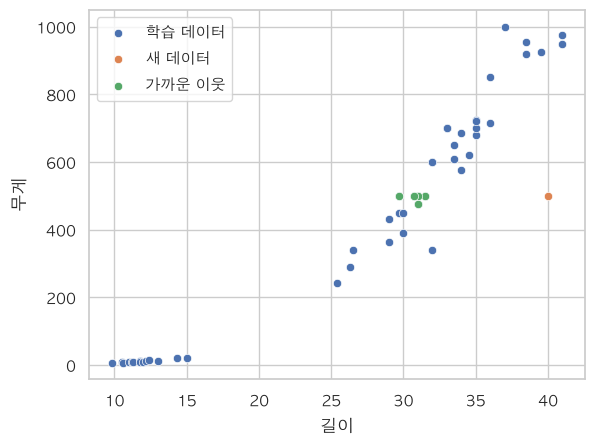

In [13]:
# 최근접 이웃을 시각화(산점도)
sns.scatterplot(
    x=fish_data[:, 0],
    y=fish_data[:, 1],
    label = '학습 데이터'
)

# 새 데이터(예측하려는 데이터)를 그래프에 표시
sns.scatterplot(x = [40], y = [500], label = '새 데이터')

distance, indices = kn_clf.kneighbors([[40, 500]], n_neighbors=5)

# 새 데이터와 이웃한 데이터의 인덱스를 5개 반환
# print(indices.squeeze())
neighbors_indices = indices.squeeze()

# 가까운 이웃한 데이터를 그래프에 표시
sns.scatterplot(
    x=fish_data[neighbors_indices, 0], # 이웃 물고기의 길이
    y=fish_data[neighbors_indices, 1], # 이웃 물고기의 무게
    label = '가까운 이웃'
)

plt.xlabel('길이')
plt.ylabel('무게')

plt.show()

## 학습/테스트 세트 분리


In [14]:
# 모든 데이터를 학습용 사용 X
# 일부는 학습, 일부는 테스트

# train_test_split() : 입력 X와 정답 y를 학습용/테스트용으로 분리
from sklearn.model_selection import train_test_split
(X_train, X_test, y_train, y_test) = train_test_split(
    fish_data, # x(문제)
    fish_target, # y(답)
    test_size= 0.2, # 전체 데이터 중 20%를 테스트용, 나머지 80% 학습용
    stratify = fish_target, # 도미, 빙어의 train/test 비율을 맞게
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (39, 2)
X_test: (10, 2)
y_train: (39,)
y_test: (10,)


In [15]:
# 1. 다시 KNN 분류 모델 생성
kn_clf = KNeighborsClassifier() # n_neighbors=5 기본값

# 2. X_train, y_train만 학습
kn_clf.fit(X_train, y_train)

# 3. 평가: X_test, y_test로 평가 점수 확인
print('테스트 점수:', kn_clf.score(X_test, y_test))

# 4. 예측: X_test를 모델에 전달할 경우 얻는 예측값 y_test와 비교
print('예측: ', kn_clf.predict(X_train))
print('정답:', y_test )

테스트 점수: 1.0
예측:  [0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 1 0
 1 1]
정답: [1 0 1 1 0 1 1 1 0 1]


## 수상한 도미
도미(길이 25, 무게 150)의 문제


In [16]:
kn_clf.predict([[25, 150]]) # 학습데이터는 다차원으로 보내야함
# 실행 결과 : array([0]) == KNN 모델이 0(빙어)로 예측

array([0])

[[ 92.00086956 130.48375378 130.73859415 138.32150953 138.39320793]] [[ 1 36 22 34  3]]
[[1 0 0 0 0]]


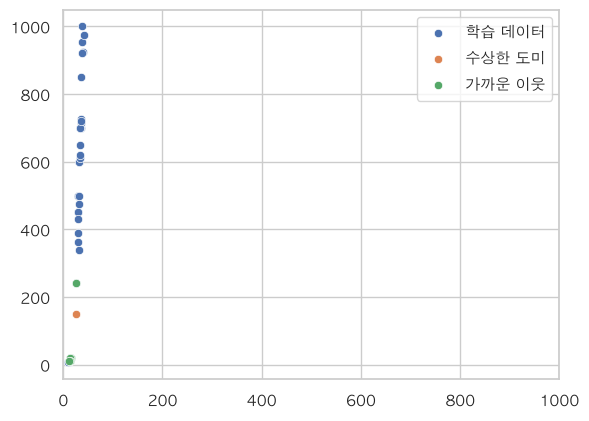

In [17]:
# 도미 데이터를 넣었는데 빙어로 예측하는 그래프로 확인
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], label='학습 데이터')
sns.scatterplot(x=[25], y=[150], label='수상한 도미')

# '수상한 도미'와 가장 가까운 이웃의 거리와 X_train 인덱스를 반환
distances, indices = kn_clf.kneighbors([[25, 150]]) # 근접한 이웃의 거리와 인덱스
print(distances, indices)

# 반환된 X_train 인덱스에 대응되는 정답 y_train 출력
print(y_train[indices])

neighbor_indices = indices.squeeze()
sns.scatterplot(
    x=X_train[neighbor_indices, 0],
    y=X_train[neighbor_indices, 1],
    label='가까운 이웃',
)
# x축 범위를 y축과 비슷하게 큰 값으로 설정하면
# 분포가 함축되어 보여 구분하기가 쉬워진다 -> KNN에서 스케일링이 필요한 이유!

plt.xlim((0, 1000))
plt.legend()
plt.show()


## 표준점수-스케일링
서로 다른 속성의 값의 범위를 맞추기 위한 전처리기법.
모델 성능에 직접적인 영향이 있음.


###  표준점수로 환산하기
표준점수(또는 Z-점수)는 데이터가 평균에서 얼마나 떨어져 있는지를 표준편차 단위로 나타낸 값이다.

$Z = \frac{X - \mu}{\sigma}$

-   $X$는 데이터 값
-   $\mu$는 데이터의 평균
-   $\sigma$는 데이터의 표준편차

특성값에서 평균을 빼고, 표준편차로 나누기.


In [18]:
# 사이킷런 제공 스케일링용 전처리 클래스
# -> 각 feature를 표준점수 z-score로 바꿔주는 전처리기
from sklearn.preprocessing import StandardScaler # 전처리 기능 제공 import

scaler = StandardScaler()

# 학습용 입력데이터(X)를 표준점수(z-score) 스케일링
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# 스케일링된 데이터를 fit() XXXXXXXXXXXXXX
# -> 스케일링 안된 데이터 + 스케일링된 데이터 -> 학습데이터 개박살남(누수)
# -> 대신 학습 데이터를 치환(변환) transform(X) 이용

print(X_test)
print(X_test_scaled)
# -> 데이터가 몰려있는 모습을 확인

[[ 26.3 290. ]
 [ 11.8  10. ]
 [ 34.  685. ]
 [ 31.  500. ]
 [ 12.4  13.4]
 [ 26.5 340. ]
 [ 35.  680. ]
 [ 34.  575. ]
 [ 11.    9.7]
 [ 41.  950. ]]
[[ 0.         -0.36984526]
 [-1.40174171 -1.26791718]
 [ 0.74437318  0.89707763]
 [ 0.45435766  0.30370868]
 [-1.3437386  -1.25701202]
 [ 0.01933437 -0.20947528]
 [ 0.84104503  0.88104063]
 [ 0.74437318  0.54426366]
 [-1.47907918 -1.2688794 ]
 [ 1.42107608  1.74703855]]


In [19]:
# 새 KNN 분류 모델 만들어서 스케일링된 데이터로 재학습
kn_clf = KNeighborsClassifier()
kn_clf.fit(X_train_scaled, y_train)
print('테스트 점수:', kn_clf.score(X_test_scaled, y_test))

테스트 점수: 1.0


In [20]:
# 수상한 도미[25, 150] 데이터를 스케일링된 데이터를 학습한 모델에게 전달
# -> 수상한 도미[25, 150]를 스케일링하여 전달!!
q = scaler.transform(([[25, 150]])) # z-score로 치환
print(q)
kn_clf.predict(q) # 스케일링 전 == 0, 스케일링 후 == 1

[[-0.12567339 -0.81888122]]


array([1])

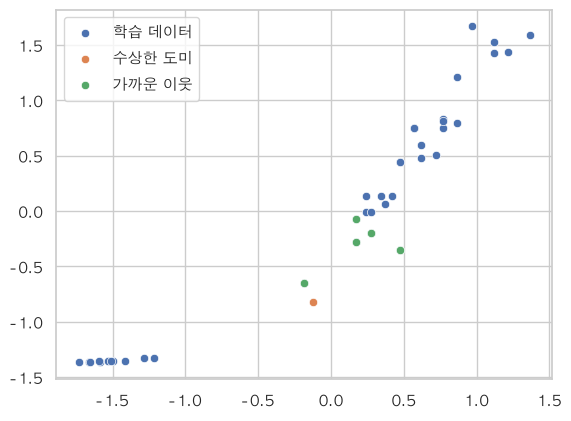

In [21]:
# 스케일링된 데이터를 이용한 시각화

# X_train_scaled[:, 0]: 스케일링된 길이
# X_train_scaled[:, 1]: 스케일링된 무게
sns.scatterplot(x=X_train_scaled[:, 0], y=X_train_scaled[:, 1], label='학습 데이터')

sns.scatterplot(x=q[:, 0], y=q[:, 1], label='수상한 도미')

distances, indices = kn_clf.kneighbors(q)
neighbor_indices = indices.squeeze()

sns.scatterplot(
    x=X_train_scaled[neighbor_indices, 0],
    y=X_train_scaled[neighbor_indices, 1],
    label='가까운 이웃',
)

plt.legend()
plt.show()

# 생선 다중분류

| Fish      | Korean Name | Image | Avg Size |
|-----------|-------------|-------|----------|
| Bream     | 도미        | <img src="https://d.pr/i/FaQ4RH+" alt="Bream" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Roach     | 붕어        | <img src="https://d.pr/i/C8jz9h+" alt="Roach" width="300px"> | 평균 길이 20~30cm *(일반적인 붕어 기준)* |
| Whitefish | 흰물고기    | <img src="https://d.pr/i/5z0jBB+" alt="Whitefish" width="300px"> | 평균 길이 30~50cm *(종류에 따라 다름)* |
| Parkki    | 파키        | <img src="https://d.pr/i/CcYfbX+" alt="Parkki" width="300px"> | 평균 길이 15~20cm *(일반적인 파키 기준)* |
| Perch     | 농어        | <img src="https://d.pr/i/JvhJwh+" alt="Perch" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Pike      | 강꼬치고기  | <img src="https://d.pr/i/NNWlsh+" alt="Pike" width="300px"> | 평균 길이 40~55cm, 최대 1m 이상<br>*(북방강꼬치고기 기준)* |
| Smelt     | 빙어        | <img src="https://d.pr/i/NmXwPX+" alt="Smelt" width="300px"> | 평균 길이 10~15cm *(빙어 기준)* |


**참고 및 설명**
- 도미(Bream)는 대표적으로 참돔을 기준으로 하였으며, 평균 길이 50~60cm, 최대 1m까지 자랍니다.
- 농어(Perch)는 실제로는 Perch(배스)와 농어(Seabass)가 다르나, 표 내 농어는 평균 50~60cm, 최대 1m 이상까지 자랍니다.
- 붕어(Roach), 파키(Parkki), 빙어(Smelt) 등은 한국 내 일반적인 평균 크기를 참고하였습니다.
- 흰물고기(Whitefish), 강꼬치고기(Pike)는 여러 종류가 있으나, 대표적인 종의 평균 크기를 기재했습니다.



In [22]:
# 데이터셋 불러오기
fish_df = pd.read_csv('data/fish.csv')
fish_df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [23]:
# 각 종마다 몇마리 있는지 확인
fish_df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [24]:
# 다중 분류 모델에 학습 시킬 입력 X, 정답 y를 분리
# X : 물고기의 수치 컬럼 5개를 담은 2차원 nd.array
# y : 각 물고기의 종류 Species 담은 1차원 nd.array
X = fish_df[['Weight', 'Length', "Diagonal", 'Height', 'Width']].to_numpy()
y = fish_df['Species'].to_numpy()
print(X.shape, y.shape)

(159, 5) (159,)


In [25]:
# 다중 분류 train/test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state=42)
#  test_size의 기본값은 0.5

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(119, 5) (119,)
(40, 5) (40,)


In [26]:
# 입력 값 X의 데이터 단위를 표준화 -> 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


# 스케일러에게 입력 값 X를 학습 -> 내부적으로 평균, 표준편차 계산
scaler.fit(X_train)


# 학습 데이터와 test 데이터를 같은 평균/표준편차를 이용해 스케일링
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)
print(X_test_scaled)

[[-7.56288032e-01 -6.60656767e-01 -6.23574459e-01 -7.80151591e-01
  -4.50436444e-01]
 [-4.59910572e-01 -1.24845300e-01 -2.44146026e-01 -4.29348704e-01
   3.51691877e-02]
 [ 7.35688553e-02  2.12851003e-02  2.16588499e-01  7.95412076e-01
   3.74817965e-01]
 [ 1.54063728e+00  1.04419790e+00  1.23743166e+00  2.29283234e+00
   1.34130358e+00]
 [-8.74839016e-01 -7.58077034e-01 -8.22322686e-01 -8.06729366e-01
  -5.69714299e-01]
 [-6.16990626e-01 -3.09943807e-01 -4.15792222e-01 -6.00632966e-01
  -1.60556561e-01]
 [-9.93390000e-01 -1.10878999e+00 -1.18368310e+00 -1.06882893e+00
  -9.36700077e-01]
 [ 8.73787997e-01  4.10966168e-01  6.23118963e-01  1.38724215e+00
   4.12802638e-01]
 [-4.00635080e-01 -2.22265567e-01 -2.08009985e-01 -2.24652384e-01
  -1.54873814e-01]
 [-4.83620769e-01 -3.29427860e-01 -1.44771913e-01  5.76145440e-01
  -2.91558819e-01]
 [-8.60020143e-01 -7.58077034e-01 -8.22322686e-01 -7.53336516e-01
  -7.17764796e-01]
 [ 1.52581841e+00  9.46777635e-01  1.12902354e+00  2.12261594e+00

In [27]:
# KNN 다중 분류 학습
from sklearn.neighbors import KNeighborsClassifier

# 가까운 이웃 3개를 보고 정답을 예측(다수결)
kn_clf = KNeighborsClassifier(n_neighbors=3)

# 학습
kn_clf.fit(X_train_scaled, y_train)

kn_clf.get_params()
print(kn_clf.classes_)
print(kn_clf.n_neighbors)
print(kn_clf.n_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
3


AttributeError: 'KNeighborsClassifier' object has no attribute 'n_'

In [ ]:
# 모델이 학습한 데이터에 대한 점수, 예측
print('학습 점수:', kn_clf.score(X_train_scaled, y_train))
print('테스트 평가 점수:', kn_clf.score(X_test_scaled, y_test))

print("예측:", kn_clf.predict(X_test_scaled))
print('정답:', y_test)

In [ ]:
# KNN이 학습 후 어떤 정보를 가지고 있는지 확인
print(kn_clf.classes_)

print(kn_clf._fit_X) # 학습 입력 데이터 X

print(kn_clf._y) # 학습 정답 데이터 y

In [ ]:
print(X_test_scaled.shape)

In [ ]:
# print(X_test_scaled[:5]) # 0~4번 행까지의 인덱스 추출

# 테스트데이터 앞 5행만 예측하고 정답과 비교
print(kn_clf.predict(X_test_scaled[:5]))
print(y_test[:5])

In [ ]:
# 예측 확률 확인
print(kn_clf.predict_proba(X_test_scaled[:5]))

## KNN 예측 확률 해석

```python
print(kn_clf.predict_proba(X_test_scaled[:5]))

위 코드는 테스트 데이터 중 앞의 5개 샘플에 대해
각 클래스에 속할 확률을 출력한 것이다.
출력 결과:

[[0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]
 [0.         0.         0.33333333 0.         0.66666667 0.
  0.        ]
 [0.         1.         0.         0.         0.         0.
  0.        ]
 [0.         0.66666667 0.         0.         0.33333333 0.
  0.        ]]

1. 결과 구조
출력 결과에서 행(row) 은 각각의 테스트 샘플을 의미한다.
행	의미
1행	첫 번째 테스트 데이터
2행	두 번째 테스트 데이터
3행	세 번째 테스트 데이터
4행	네 번째 테스트 데이터
5행	다섯 번째 테스트 데이터

그리고 열(column) 은 각각의 클래스를 의미한다.
현재 결과에는 열이 7개 있으므로, 모델이 예측할 수 있는 클래스가 총 7개라는 뜻이다.
각 열이 어떤 클래스를 의미하는지는 다음 코드로 확인할 수 있다.
kn_clf.classes_
예를 들어 결과가 다음과 같다면:
array([0, 1, 2, 3, 4, 5, 6])
각 열은 아래와 같이 해석할 수 있다.
열 번호	클래스
0번째 열	클래스 0
1번째 열	클래스 1
2번째 열	클래스 2
3번째 열	클래스 3
4번째 열	클래스 4
5번째 열	클래스 5
6번째 열	클래스 6

2. 첫 번째 샘플 해석
첫 번째 행은 다음과 같다.
[0. 0. 0.66666667 0. 0.33333333 0. 0.]
이는 첫 번째 테스트 데이터가 각 클래스에 속할 확률을 의미한다.
클래스	확률
클래스 0	0%
클래스 1	0%
클래스 2	66.7%
클래스 3	0%
클래스 4	33.3%
클래스 5	0%
클래스 6	0%

가장 높은 확률은 클래스 2의 66.7%이다.
따라서 첫 번째 샘플의 최종 예측값은 클래스 2가 된다.
3. 각 샘플별 예측 해석
클래스가 [0, 1, 2, 3, 4, 5, 6]이라고 가정하면 다음과 같이 해석할 수 있다.
샘플	가장 높은 확률	예측 클래스
1번째 샘플	클래스 2: 66.7%	클래스 2
2번째 샘플	클래스 2: 66.7%	클래스 2
3번째 샘플	클래스 4: 66.7%	클래스 4
4번째 샘플	클래스 1: 100%	클래스 1
5번째 샘플	클래스 1: 66.7%	클래스 1

즉, 최종 예측 결과는 다음과 비슷하게 나온다.
kn_clf.predict(X_test_scaled[:5])
예상 결과:
array([2, 2, 4, 1, 1])
4. 왜 0.6667, 0.3333이 나오는가?
KNN은 주변의 가까운 이웃들을 보고 다수결로 예측한다.
예를 들어 n_neighbors=3이라면, 가장 가까운 이웃 3개를 확인한다.
만약 가까운 이웃 3개 중에서:
클래스 2가 2개
클래스 4가 1개
라면 확률은 다음과 같이 계산된다.
클래스 2 확률 = 2 / 3 = 0.6667
클래스 4 확률 = 1 / 3 = 0.3333
그래서 결과가 다음처럼 나온다.
[0. 0. 0.6667 0. 0.3333 0. 0.]
5. 확률 결과를 보기 좋게 출력하기
확률 결과를 표 형태로 보고 싶으면 다음과 같이 작성할 수 있다.
import pandas as pd

proba = kn_clf.predict_proba(X_test_scaled[:5])

pd.DataFrame(
    proba,
    columns=kn_clf.classes_
)
이렇게 하면 각 클래스별 확률을 DataFrame 형태로 확인할 수 있다.
6. 핵심 정리
predict_proba()는 각 클래스에 속할 확률을 출력한다.
결과의 행은 각각의 데이터 샘플을 의미한다.
결과의 열은 각각의 클래스를 의미한다.
각 행에서 가장 큰 확률을 가진 클래스가 최종 예측값이 된다.
KNN에서는 가까운 이웃들의 비율에 따라 확률이 계산된다.

In [ ]:
# 다중 분류에서 kneighbor()로 예측 근거가 된 이웃 찾기
distances, indices = kn_clf.kneighbors(X_test_scaled[:1])  # X_test_scaled[0]
print(X_test_scaled[0])
print(distances)
print(indices)

print(y_train[indices])

## @실습문제: 붓꽃 다중 분류

붓꽃은 세포핵을 둘러싼 꽃받침(sepal)과 꽃잎(petal)으로 구성되어 있으며, 이러한 특징을 기반으로 붓꽃의 품종을 식별할 수 있습니다.

- Setosa (세토사): Setosa는 붓꽃 중에서 가장 작은 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎과 꽃받침이 비교적 짧고 뾰족한 모습을 갖고 있으며, 주로 흰색 또는 연한 분홍색을 띠고 있습니다.

- Versicolor (버시컬러): Versicolor는 Setosa보다 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 보통 연한 보라색이며, 중간 크기의 붓꽃입니다.

- Virginica (버지니카): Virginica는 붓꽃 중에서 가장 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 주로 짙은 보라색이며, 다른 품종들에 비해 상대적으로 더 큰 크기를 갖고 있습니다.

![](https://d.pr/i/4egoon+)


In [ ]:
# scikit-learn에서 iris 데이터셋 얻어오기
from sklearn.datasets import load_iris

iris = load_iris()
# print(iris.data) # 입력 X
# print(iris.target) # 정답 y
print(iris.feature_names)
print(iris.target_names)

In [ ]:
iris_df = pd.DataFrame(
    iris.data, #  X
    columns=iris.feature_names
)

iris_df['target'] = iris.target

iris_df

In [ ]:
# 1. train/test split
X_train, X_test, y_train, y_test = train_test_split(
    iris.data,    # 입력 X
    iris.target,  # 정답 y
    stratify=iris.target,
    random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# 2. 스케일링
scaler = StandardScaler()
scaler.fit(X_train) # X_train기준 평균, 표준편차 학습

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 3. KNN 분류 모델 생성 + 학습 fit()
kn_clf = KNeighborsClassifier(n_neighbors=3)
kn_clf.fit(X_train_scaled, y_train)

# 4. 평가  score()
print("학습 데이터셋 평가 : ", kn_clf.score(X_train_scaled, y_train))
print("테이스 데이터셋 평가 : ", kn_clf.score(X_test_scaled, y_test))

# 5. 예측 predict() - test 데이터 일부와, 실제 정답을 비교
print("예측: ", kn_clf.predict(X_test_scaled[:5]))
print("정답: ", y_test[:5])